# Kaggle – Data on the top — 03 · XGBoost (mejor modelo)

Tu profe ha comprado una tienda de portátiles y quiere un modelo de ML para fijar precios.

**Este notebook (3/3):** apostamos por el mejor RMSE con **Gradient Boosting (XGBoost)**. Comparamos también con LightGBM y un *blend*, pero el XGBoost individual es el ganador.

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [3]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 92.8 KB


In [5]:
# Tipos, nulos y cardinalidad de cada columna
pd.DataFrame({'dtype': df.dtypes, 'nulos': df.isna().sum(), 'únicos': df.nunique()})

,dtype,nulos,únicos
laptop_ID,int64,0,912
Company,str,0,19
Product,str,0,480
TypeName,str,0,6
Inches,float64,0,17
ScreenResolution,str,0,36
Cpu,str,0,107
Ram,str,0,9
Memory,str,0,37
Gpu,str,0,93


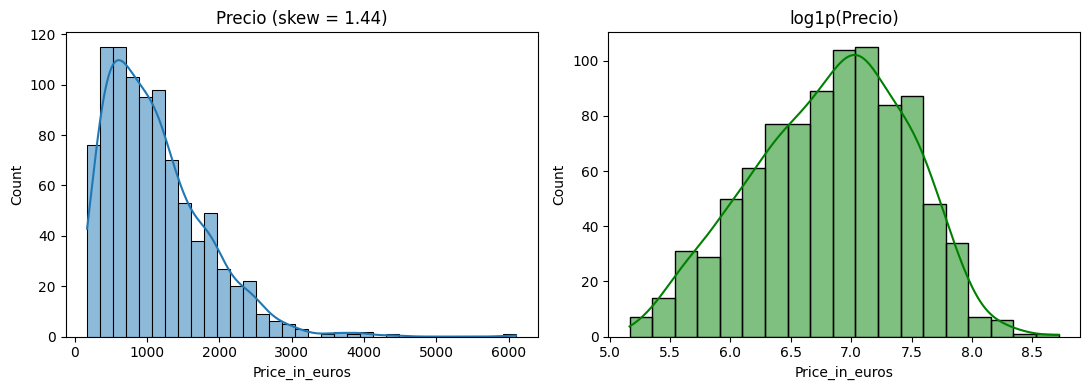

In [6]:
# El target está muy sesgado a la derecha -> log1p lo aproxima a una normal
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Price_in_euros'], kde=True, ax=ax[0])
ax[0].set_title(f"Precio (skew = {df['Price_in_euros'].skew():.2f})")
sns.histplot(np.log1p(df['Price_in_euros']), kde=True, color='green', ax=ax[1])
ax[1].set_title('log1p(Precio)')
plt.tight_layout(); plt.show()

**Observaciones clave**

- **Sin valores nulos** y, comprobado aparte, **ninguna categoría de `test.csv` falta en `train.csv`** → codificar es seguro.
- El **precio está sesgado** (skew ≈ 1.4). Para los modelos lineales entrenaremos sobre `log1p(precio)` y desharemos la transformación con `expm1` al predecir.
- El valor real está en las **columnas de texto** (`Cpu`, `Memory`, `ScreenResolution`...): hay que *parsearlas* (sección 3).
- `Product` tiene 480 valores únicos → se descarta (cardinalidad demasiado alta).

### 2.2 Definir X e y

In [7]:
y = df['Price_in_euros']                      # target
X = df.drop(columns=['Price_in_euros'])       # predictores (aún en crudo)
X.shape, y.shape

((912, 12), (912,))

### 2.3 Dividir en train y test

Reservamos un 20% como conjunto de validación local para estimar el RMSE antes de subir a Kaggle.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((729, 12), (183, 12))

## 3. Procesado de datos

Mismo *feature engineering*. Para árboles basta con **One-Hot** en las categóricas; las numéricas pasan sin escalar. El `OneHotEncoder` se ajusta **solo con `X_train`** dentro del `Pipeline`.

In [9]:
import re

def cpu_category(s):
    """Gama de CPU a partir del texto (i7/i5/i3, Celeron, Ryzen...)."""
    s = s.lower()
    if 'i7' in s:      return 'Intel Core i7'
    if 'i5' in s:      return 'Intel Core i5'
    if 'i3' in s:      return 'Intel Core i3'
    if 'celeron' in s: return 'Intel Celeron'
    if 'pentium' in s: return 'Intel Pentium'
    if 'atom' in s:    return 'Intel Atom'
    if 'xeon' in s:    return 'Intel Xeon'
    if 'ryzen' in s:   return 'AMD Ryzen'
    return 'AMD Other' if 'amd' in s else 'Other'

def parse_memory(mem):
    """'128GB SSD +  1TB HDD' -> GB por tipo de almacenamiento."""
    out = {'ssd': 0.0, 'hdd': 0.0, 'flash': 0.0, 'hybrid': 0.0}
    for parte in mem.split('+'):
        m = re.search(r'([\d\.]+)\s*(TB|GB)', parte)
        if not m:
            continue
        size = float(m.group(1)) * (1000 if m.group(2) == 'TB' else 1)  # TB -> GB
        if   'SSD'    in parte: out['ssd']    += size
        elif 'HDD'    in parte: out['hdd']    += size
        elif 'Hybrid' in parte: out['hybrid'] += size
        elif 'Flash'  in parte: out['flash']  += size
    return pd.Series(out)

def simplify_os(s):
    s = s.lower()
    if 'windows' in s: return 'Windows'
    if 'mac' in s:     return 'Mac'
    if 'linux' in s:   return 'Linux'
    if 'chrome' in s:  return 'Chrome'
    if 'android' in s: return 'Android'
    return 'No OS'

def feature_engineering(df):
    """Convierte las columnas de texto crudo en variables numéricas/categóricas.

    Es 100% fila-a-fila (NO usa .fit ni estadísticas globales), por lo que
    aplicarla a test.csv NO produce data leakage.
    """
    df = df.copy()
    # 1) RAM y peso -> número
    df['Ram']    = df['Ram'].str.replace('GB', '', regex=False).astype(int)
    df['Weight'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)
    # 2) Pantalla -> resolución, PPI (densidad de píxeles), táctil, IPS
    res = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)
    df['res_w'], df['res_h'] = res[0], res[1]
    df['ppi']    = np.sqrt(df['res_w']**2 + df['res_h']**2) / df['Inches']
    df['pixels'] = df['res_w'] * df['res_h']
    df['touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype(int)
    df['ips']         = df['ScreenResolution'].str.contains('IPS').astype(int)
    # 3) CPU -> GHz, gama y marca
    df['cpu_ghz']   = df['Cpu'].str.extract(r'([\d\.]+)GHz').astype(float)
    df['cpu_cat']   = df['Cpu'].apply(cpu_category)
    df['cpu_brand'] = df['Cpu'].str.split().str[0]
    # 4) GPU -> marca y si es de gama alta (gaming / workstation)
    df['gpu_brand']   = df['Gpu'].str.split().str[0]
    df['gpu_highend'] = df['Gpu'].str.contains('GTX|RTX|Quadro|Pro |Vega|Radeon RX',
                                               case=False, regex=True).astype(int)
    # 5) Almacenamiento -> GB por tipo + total + flag de SSD
    df = pd.concat([df, df['Memory'].apply(parse_memory)], axis=1)
    df['storage_total'] = df['ssd'] + df['hdd'] + df['flash'] + df['hybrid']
    df['has_ssd']       = (df['ssd'] > 0).astype(int)
    # 6) Sistema operativo simplificado
    df['os'] = df['OpSys'].apply(simplify_os)
    return df

In [10]:
X_train = feature_engineering(X_train)
X_test  = feature_engineering(X_test)

In [11]:
# Variables que entran al modelo
num_cols = ['Inches', 'Ram', 'Weight', 'res_w', 'res_h', 'ppi', 'pixels',
            'touchscreen', 'ips', 'cpu_ghz', 'ssd', 'hdd', 'flash', 'hybrid',
            'storage_total', 'has_ssd', 'gpu_highend']
cat_cols = ['Company', 'TypeName', 'cpu_cat', 'cpu_brand', 'gpu_brand', 'os']

# 'Product' (480 valores únicos) y 'laptop_ID' NO se usan como predictores.
print(f'{len(num_cols)} numéricas + {len(cat_cols)} categóricas')

17 numéricas + 6 categóricas


In [12]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

## 4. Modelado

### 4.1 Entrenamiento

XGBoost con hiperparámetros razonables, **sobre el precio en euros** (ver 4.3).

In [13]:
xgb = Pipeline([('pre', preprocessor),
                ('m', XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8, reg_lambda=1,
                                   random_state=42, n_jobs=-1))])
xgb.fit(X_train[num_cols + cat_cols], y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse

### 4.2 Métricas

In [14]:
rmse_xgb = root_mean_squared_error(y_test, xgb.predict(X_test[num_cols + cat_cols]))
print(f'RMSE validación — XGBoost: {rmse_xgb:.2f} €')

RMSE validación — XGBoost: 283.60 €


### 4.3 Optimización (up to you 🫰🏻)

**(a) ¿log o no log?** En los lineales el `log` ayudaba. En boosting, cuyo objetivo ya es el error cuadrático en euros, entrenar sobre el precio directo suele ser mejor:

In [15]:
xgb_log = Pipeline([('pre', preprocessor),
                    ('m', XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=4,
                                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1,
                                       random_state=42, n_jobs=-1))])
xgb_log.fit(X_train[num_cols + cat_cols], np.log1p(y_train))
rmse_log = root_mean_squared_error(y_test, np.expm1(xgb_log.predict(X_test[num_cols + cat_cols])))
print(f'XGBoost SIN log: {rmse_xgb:.2f} €')
print(f'XGBoost CON log: {rmse_log:.2f} €')

XGBoost SIN log: 283.60 €
XGBoost CON log: 288.83 €


**(b) Búsqueda de hiperparámetros** con `RandomizedSearchCV` (5-fold) alrededor de la zona buena:

In [16]:
param_dist = {
    'm__n_estimators':     [500, 600, 700, 800],
    'm__learning_rate':    [0.03, 0.05, 0.07],
    'm__max_depth':        [3, 4, 5],
    'm__subsample':        [0.7, 0.8, 0.9],
    'm__colsample_bytree': [0.7, 0.8, 1.0],
    'm__reg_lambda':       [0.5, 1, 2],
}
search = RandomizedSearchCV(xgb, param_dist, n_iter=25,
                            scoring='neg_root_mean_squared_error',
                            cv=KFold(5, shuffle=True, random_state=42),
                            random_state=42, n_jobs=-1)
search.fit(X_train[num_cols + cat_cols], y_train)
print('Mejores params:', {k.replace('m__', ''): v for k, v in search.best_params_.items()})
print(f'Mejor RMSE CV : {-search.best_score_:.2f} €')

Mejores params: {'subsample': 0.7, 'reg_lambda': 0.5, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Mejor RMSE CV : 271.14 €


**(c) ¿Y un LightGBM o un *blend*?** Lo comprobamos con validación cruzada (5-fold, en euros):

In [17]:
def cv_rmse(estimator):
    sc = cross_val_score(estimator, X_train[num_cols + cat_cols], y_train,
                         scoring='neg_root_mean_squared_error',
                         cv=KFold(5, shuffle=True, random_state=42), n_jobs=-1)
    return -sc.mean()

lgbm = Pipeline([('pre', preprocessor),
                 ('m', LGBMRegressor(n_estimators=600, learning_rate=0.05, num_leaves=31,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=42, n_jobs=-1, verbose=-1))])
print(f'XGBoost  CV: {cv_rmse(xgb):.2f} €')
print(f'LightGBM CV: {cv_rmse(lgbm):.2f} €')

XGBoost  CV: 279.42 €


LightGBM CV: 292.70 €


El XGBoost individual es el mejor (LightGBM y los *blends* no lo superan de forma consistente, y la diferencia cae dentro del ruido de la CV). Nos quedamos con él por **mejor RMSE y simplicidad**.

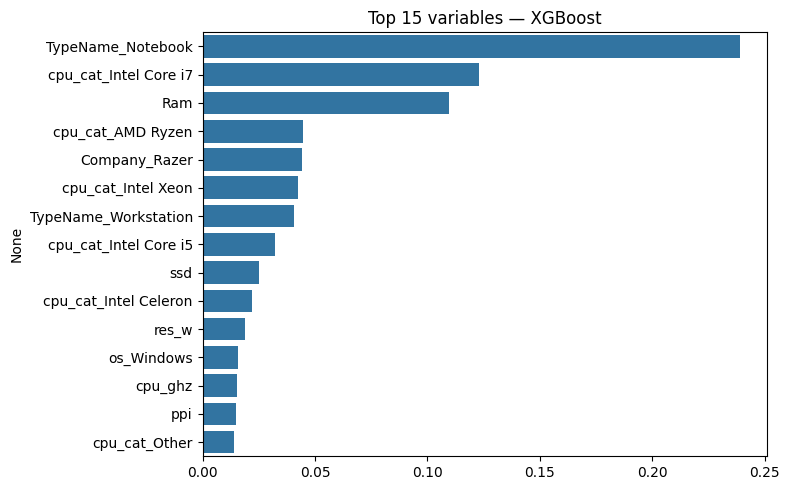

In [18]:
# Importancia de variables del XGBoost afinado
mejor = search.best_estimator_
ohe = mejor.named_steps['pre'].named_transformers_['cat']
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
imp = pd.Series(mejor.named_steps['m'].feature_importances_,
                index=feat_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5)); sns.barplot(x=imp.values, y=imp.index)
plt.title('Top 15 variables — XGBoost'); plt.tight_layout(); plt.show()

## 5. Reentrenamiento sobre todos los datos de `train.csv`

In [19]:
X_all = feature_engineering(X)
modelo_final = search.best_estimator_            # XGBoost con los mejores hiperparámetros
modelo_final.fit(X_all[num_cols + cat_cols], y)  # reentrena con TODO train (sin log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse

---
# PARTE 2: Predicción y submission

## 6. Carga los datos de `test.csv`

In [20]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

Aplicamos **la misma** función `feature_engineering` (es fila-a-fila, sin `.fit`). El escalado/codificación lo hace el `Pipeline` con `.transform()` usando lo aprendido en train → **sin leakage**.

In [21]:
X_pred_fe = feature_engineering(X_pred)
X_pred_fe[num_cols + cat_cols].isna().sum().sum()  # debe ser 0

np.int64(0)

## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [22]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [23]:
# XGBoost sobre el precio en euros (sin log)
preds = modelo_final.predict(X_pred_fe[num_cols + cat_cols])
submission = pd.DataFrame({'laptop_ID': X_pred['laptop_ID'], 'Price_in_euros': preds})
print('Rango de predicciones: %.0f - %.0f €' % (preds.min(), preds.max()))
submission.head()

Rango de predicciones: 218 - 5531 €


,laptop_ID,Price_in_euros
0,209,1244.104370
1,1281,275.503113
2,1168,365.150970
3,1231,942.899719
4,1020,1117.167236


### 8.3 Chequeador

Valida la forma y, si todo está bien, guarda el CSV listo para subir.

In [24]:
def checker(df_to_submit, sample, filename=None):
    """Valida que la submission tenga la forma requerida por Kaggle y la guarda."""
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        return
    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        return
    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission.')
        return
    if filename is None:
        from datetime import datetime
        filename = f"submission_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [25]:
checker(submission, sample, filename='submission_03_xgboost.csv')

 ¡Todo correcto! Submission guardada como 'submission_03_xgboost.csv'. ¡A Kaggle!
